# EfficientNet-B3

## Changes from ResNet-18 Unfreeze Baseline

### What changed
| | ResNet-18 Unfreeze | EfficientNet-B3 |
|---|---|---|
| Architecture | ResNet-18 (~11M params) | EfficientNet-B3 (~12M params) |
| Input size | 224×224 | 300×300 |
| Optimizer | Adam | AdamW (decoupled weight decay) |
| Weight decay | None | 1e-4 |
| LR scheduler | None | CosineAnnealingLR |
| Augmentation | Basic (h-flip, ±10° rotation) | Strong (v-flip, ±30°, ColorJitter, RandomAffine) |

### Rationale
EfficientNet-B3 scales depth, width, and resolution together using a compound coefficient, achieving significantly better accuracy per parameter than ResNet-18 (ImageNet Top-1: 82.0% vs 69.8%). Its native 300×300 input captures finer dermatological features — texture, border irregularity, and colour variation — that are important for melanoma detection.

All lessons from the ResNet experiments are applied from the start:
- **Full fine-tuning**: Unfreezing the backbone was the dominant improvement (+9pp recall) in ResNet experiments
- **AdamW + CosineAnnealingLR**: Better optimisation dynamics than plain Adam
- **No dropout**: aug_v2 showed 0.4 dropout hurt recall significantly; excluded here
- **Augmented transforms at 300×300**: Reduces overfitting without aggressively constraining recall

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [ ]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [2]:
use_mps = True
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('mps' if (use_mps and torch.backends.mps.is_available()) else 'cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


In [3]:
IMAGE_SIZE = 224

train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=32,
    image_size=IMAGE_SIZE,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=IMAGE_SIZE),
)

train_df = pd.read_csv('../data/splits/train.csv')

num_melanoma = (train_df['label'] == 0).sum()   # melanoma in CSV (label=0 → inverted to 1)
num_nevus = (train_df['label'] == 1).sum()      # nevus in CSV (label=1 → inverted to 0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_efficientnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

Positive weight: tensor([6.0244], device='mps:0')


In [4]:
best_val_f2 = 0.0

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), '../models/efficientnet_b3_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.8277, Acc: 0.7427, Recall: 0.8151, F2: 0.6331 | Val Loss: 0.6690, Acc: 0.7570, Recall: 0.8982, F2: 0.6906
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.6321, Acc: 0.8072, Recall: 0.8575, F2: 0.7064 | Val Loss: 0.6375, Acc: 0.7272, Recall: 0.9042, F2: 0.6723


Epoch [3/20] | Train Loss: 0.5736, Acc: 0.8240, Recall: 0.8639, F2: 0.7243 | Val Loss: 0.5792, Acc: 0.8397, Recall: 0.8144, F2: 0.7076
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.5138, Acc: 0.8436, Recall: 0.8947, F2: 0.7598 | Val Loss: 0.5886, Acc: 0.8457, Recall: 0.8084, F2: 0.7090
Saved best model at epoch 4


Epoch [5/20] | Train Loss: 0.4880, Acc: 0.8560, Recall: 0.9076, F2: 0.7788 | Val Loss: 0.6157, Acc: 0.7971, Recall: 0.8563, F2: 0.6976


...

Epoch [16/20] | Train Loss: 0.2192, Acc: 0.9443, Recall: 0.9628, F2: 0.9054 | Val Loss: 0.7234, Acc: 0.8670, Recall: 0.8383, F2: 0.7471


Epoch [17/20] | Train Loss: 0.1999, Acc: 0.9444, Recall: 0.9769, F2: 0.9140 | Val Loss: 0.7512, Acc: 0.8755, Recall: 0.8263, F2: 0.7476


Epoch [18/20] | Train Loss: 0.2098, Acc: 0.9452, Recall: 0.9641, F2: 0.9072 | Val Loss: 0.7302, Acc: 0.8713, Recall: 0.8144, F2: 0.7359


Epoch [19/20] | Train Loss: 0.2287, Acc: 0.9443, Recall: 0.9576, F2: 0.9023 | Val Loss: 0.7486, Acc: 0.8798, Recall: 0.8204, F2: 0.7478


Epoch [20/20] | Train Loss: 0.1966, Acc: 0.9432, Recall: 0.9782, F2: 0.9132 | Val Loss: 0.7491, Acc: 0.8824, Recall: 0.8204, F2: 0.7503


## Plot Loss and Accuracy Curves

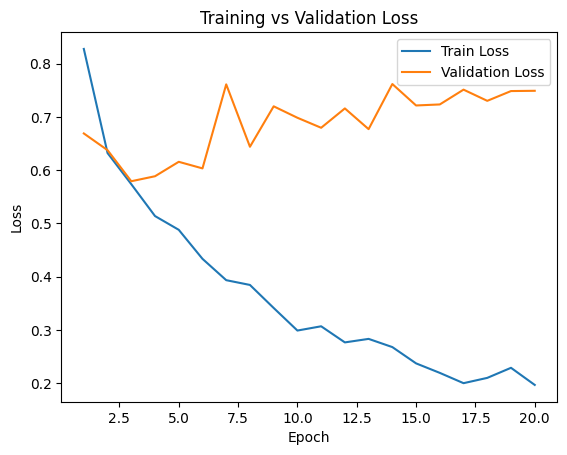

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

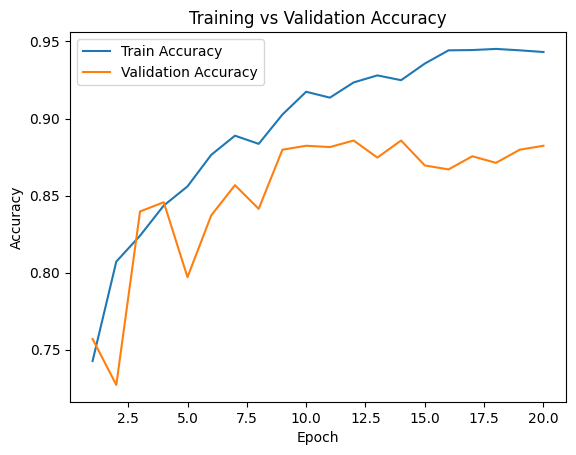

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

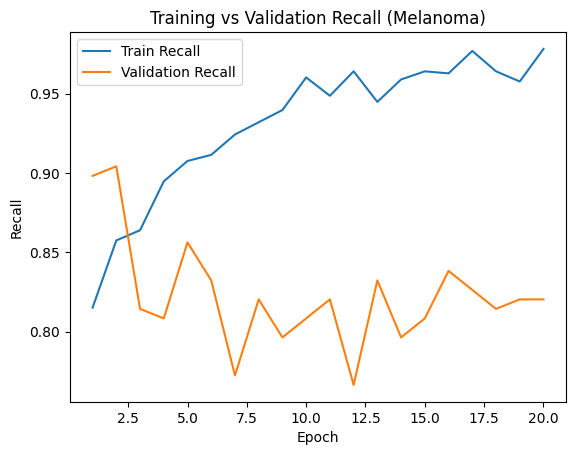

In [7]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

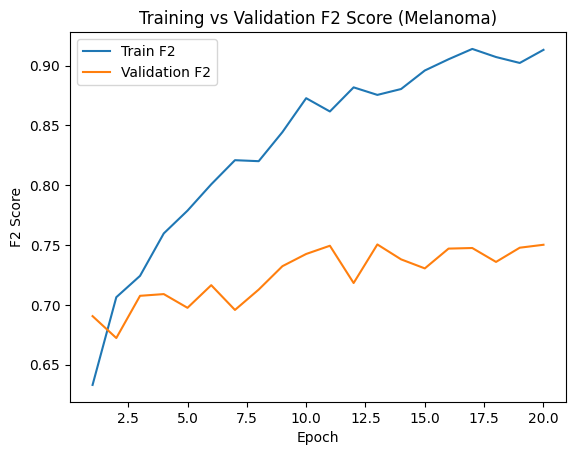

In [8]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [9]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load('../models/efficientnet_b3_best.pth', map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.63 | Val F2: 0.7593


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [11]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[935  71]
 [ 29 138]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [12]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9699    0.9294    0.9492      1006
           1     0.6603    0.8263    0.7340       167

    accuracy                         0.9147      1173
   macro avg     0.8151    0.8779    0.8416      1173
weighted avg     0.9258    0.9147    0.9186      1173



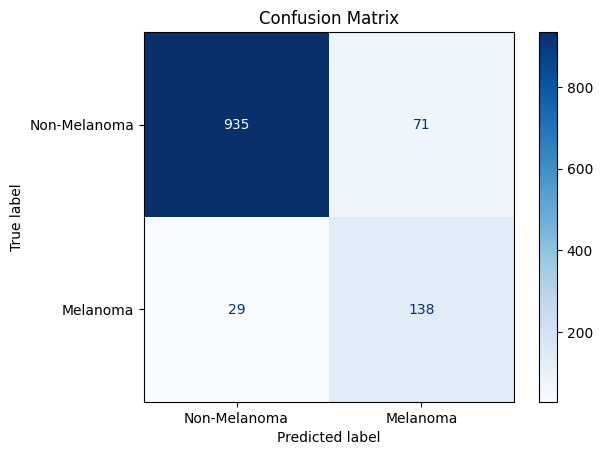

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()